# Método da descida do gradiente (gradient descent)

**Francisco Aparecido Rodrigues**  
Universidade de São Paulo, São Carlos, Brasil  
<https://sites.icmc.usp.br/francisco>  

<hr>

A **descida do gradiente** é um algoritmo de otimização iterativo, usado para encontrar os parâmetros de um modelo que **minimizam** uma função de custo $J$. A ideia é simples e intuitiva: em cada parâmetro do modelo, o gradiente $\nabla J$ aponta na direção de **maior crescimento** da função de custo; logo, andando na direção **oposta** ao gradiente, damos um passo que **reduz** o custo. Repetindo esse processo muitas vezes, os parâmetros convergem para um mínimo (idealmente, o mínimo global) da função de custo.

Formalmente, a cada iteração de treinamento, isto é, após o processamento de um batch, atualizamos cada parâmetro $\theta$ do modelo segundo a regra:

$$\theta \leftarrow \theta - \eta \, \frac{\partial J}{\partial \theta}$$

em que:

- $\dfrac{\partial J}{\partial \theta}$ é a derivada parcial (o **gradiente**) da função de custo em relação ao parâmetro $\theta$. Ela nos diz o quanto e em que sentido o custo aumentaria se $\theta$ aumentasse;
- $\eta$ é a **taxa de aprendizado** (*learning rate*), um hiperparâmetro que controla o tamanho do passo dado a cada atualização. Se $\eta$ for **grande demais**, os passos podem ser tão largos que o algoritmo "pula" o mínimo e diverge (o custo passa a aumentar, em vez de diminuir); se for **pequeno demais**, a convergência fica extremamente lenta, exigindo muitas épocas para chegar perto do mínimo;

Neste notebook, vamos aplicar a descida do gradiente a três modelos diferentes, isto é **regressão linear simples**, **regressão linear múltipla** e **regressão logística** e comparar os resultados com a solução do **scikit-learn** em cada caso. 

## Regressão linear simples

Na regressão linear simples, modelamos a relação entre um único atributo $x$ e o alvo $y$ por uma reta:

$$\hat{y}_i = \beta_0 + \beta_1 x_i$$

em que $\beta_0$ é o intercepto (o valor previsto quando $x=0$) e $\beta_1$ é a inclinação da reta (o quanto $\hat y$ muda para cada unidade de aumento em $x$). Queremos escolher $\beta_0$ e $\beta_1$ de forma a minimizar o **erro quadrático médio (MSE)** entre os valores previstos e os valores reais. Assim, a função de custo:

$$J(\beta_0, \beta_1) = \frac{1}{n}\sum_{i=1}^{n}\left(y_i - \hat{y}_i\right)^2$$

Para aplicar a descida do gradiente, precisamos das derivadas parciais de $J$ em relação a cada parâmetro. Calculando-as (usando a regra da cadeia), obtemos:

$$\frac{\partial J}{\partial \beta_0} = -\frac{2}{n}\sum_{i=1}^{n}\left(y_i - \hat{y}_i\right) \qquad\qquad \frac{\partial J}{\partial \beta_1} = -\frac{2}{n}\sum_{i=1}^{n}\left(y_i - \hat{y}_i\right)x_i$$

Ou seja: o gradiente de $\beta_0$ é (menos duas vezes) a média dos erros, e o gradiente de $\beta_1$ é (menos duas vezes) a média dos erros ponderados pelo valor de $x$ correspondente. É exatamente essa fórmula que vamos traduzir em código a seguir.

Substituindo as derivadas, as regras de atualização podem ser escritas como:

$$
\beta_0
\leftarrow
\beta_0
+
\eta
\frac{2}{n}
\sum_{i=1}^{n}
\left(y_i-\hat{y}_i\right)
$$

$$
\beta_1
\leftarrow
\beta_1
+
\eta
\frac{2}{n}
\sum_{i=1}^{n}
\left(y_i-\hat{y}_i\right)x_i
$$

Essas atualizações são repetidas durante várias iterações. A cada passo, a reta é ajustada com o objetivo de reduzir progressivamente a função de custo. É importante que $\beta_0$ e $\beta_1$ sejam atualizados simultaneamente, utilizando os valores do gradiente calculados antes de qualquer alteração nos parâmetros.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Dados de treinamento 
x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]) 
y = np.array([1, 3, 2, 5, 7, 8, 8, 9, 10, 12]) 
n = len(x)  # número de observações

# Inicialização dos parâmetros
# É comum começar com os parâmetros em zero (ou em valores aleatórios pequenos);
# a descida do gradiente vai ajustá-los progressivamente.
beta0 = 0.0   # intercepto
beta1 = 0.0   # inclinação

eta = 0.03   # taxa de aprendizado
epochs = 50  # número de épocas (passos de atualização)

# Lista para guardar o valor da função de custo a cada época,
# o que vai nos permitir visualizar a convergência do algoritmo mais adiante.
cost_history = []

# Treinamento por descida do gradiente
# Uma época corresponde a uma passagem completa por todo o conjunto de treinamento.
for epoch in range(epochs):
    # Previsão do modelo com os parâmetros atuais
    y_hat = beta0 + beta1 * x

    # Erro entre o valor real e o valor previsto
    erro = y - y_hat

    # Gradientes da função de custo (MSE) em relação a beta0 e beta1 (ver dedução acima)
    d_beta0 = (-2/n) * np.sum(erro)
    d_beta1 = (-2/n) * np.sum(erro * x)

    # Atualiza os parâmetros na direção oposta ao gradiente
    beta0 = beta0 - eta * d_beta0
    beta1 = beta1 - eta * d_beta1

    # Guarda o valor do custo (MSE) nesta época, para podermos visualizar depois
    custo = np.mean(erro ** 2)
    cost_history.append(custo)

# Resultado final
print("Parâmetros estimados pela descida do gradiente:")
print("beta0 =", beta0)
print("beta1 =", beta1)

Parâmetros estimados pela descida do gradiente:
beta0 = 0.8006794896004014
beta1 = 1.2391766337034835


Dois gráficos ajudam a compreender o que ocorreu durante o treinamento: **a curva sigmoide ajustada aos dados originais** e a **evolução da função de custo ao longo das épocas**.

O segundo é especialmente importante em modelos treinados por descida do gradiente, pois permite verificar se o algoritmo está convergindo. Em um treinamento adequado, o custo geralmente diminui de forma mais acentuada nas primeiras épocas e, em seguida, passa a variar cada vez menos, estabilizando-se próximo de um valor mínimo. Se o custo não diminuir, oscilar excessivamente ou aumentar, isso pode indicar problemas como uma taxa de aprendizado inadequada ou erros na implementação do algoritmo.

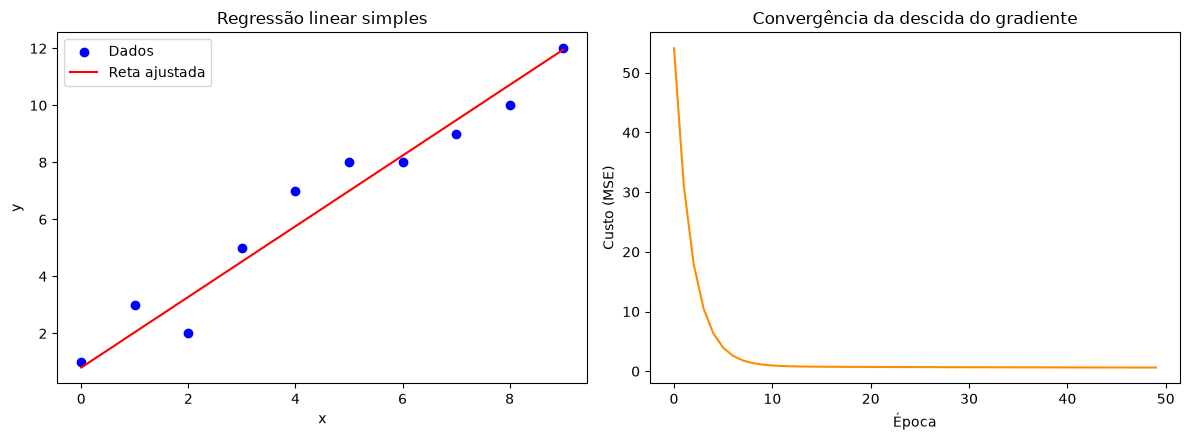

Valor observado: y= 7
Previsão para x=4: 5.757386024414336


In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Gráfico 1: dados e reta ajustada
ax1.scatter(x, y, color='blue', label='Dados')
ax1.plot(x, beta0 + beta1 * x, color='red', label='Reta ajustada')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Regressão linear simples')
ax1.legend()

# Gráfico 2: evolução do custo (MSE) ao longo das épocas
ax2.plot(cost_history, color='darkorange')
ax2.set_xlabel('Época')
ax2.set_ylabel('Custo (MSE)')
ax2.set_title('Convergência da descida do gradiente')

plt.tight_layout()
plt.show()

# -----------------------------
# Previsão para um novo valor de x
# -----------------------------
i = 4
x_novo = np.array([[i]])              # novo ponto para o qual queremos prever y
y_pred = beta0 + beta1 * x_novo
print(f"Valor observado: y=", y[i])
print(f"Previsão para x={x_novo[0][0]}:", y_pred[0][0])

Note como o custo cai rapidamente nas primeiras épocas e depois se estabiliza. Esse é um sinal de que o algoritmo convergiu (ou está muito próximo do mínimo) com essa combinação de taxa de aprendizado e número de épocas. Se a curva ainda estivesse caindo de forma acentuada ao final, valeria a pena treinar por mais épocas; se ela oscilasse (subindo e descendo), seria sinal de uma taxa de aprendizado grande demais.

Para confirmar que nossa implementação manual está correta, vamos ajustar o mesmo modelo com a classe `LinearRegression` do scikit-learn, que resolve a regressão linear de forma exata (por mínimos quadrados, sem precisar de descida do gradiente). Os parâmetros encontrados pelos dois métodos devem ser bem próximos.

Parâmetros estimados (scikit-learn):
Intercepto (beta0): 1.2363636363636363
Coeficiente (beta1): 1.1696969696969697

Comparação com a descida do gradiente (manual):
  beta0: manual = 0.8007   |   scikit-learn = 1.2364
  beta1: manual = 1.2392   |   scikit-learn = 1.1697


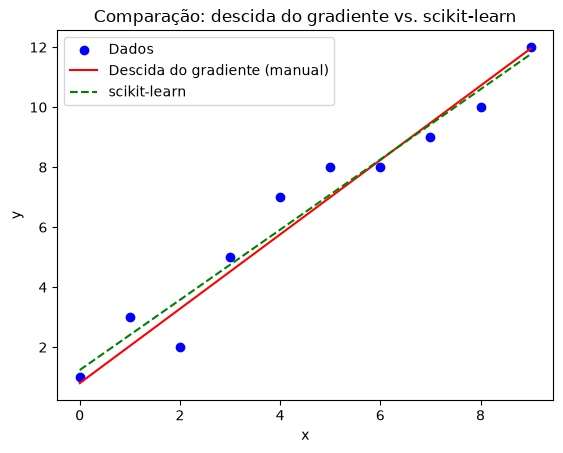

Valor observado: y= 7

Previsão do scikit-learn para x=4: 5.915151515151515


In [3]:
from sklearn.linear_model import LinearRegression

# O scikit-learn espera que os atributos (X) estejam em um array 2D,
# com uma linha por observação e uma coluna por atributo -- por isso o reshape.
x_sk = x.reshape(-1, 1)
y_sk = y

# Cria e ajusta o modelo (por mínimos quadrados, não por descida do gradiente)
model_sk = LinearRegression()
model_sk.fit(x_sk, y_sk)

print("Parâmetros estimados (scikit-learn):")
print("Intercepto (beta0):", model_sk.intercept_)
print("Coeficiente (beta1):", model_sk.coef_[0])

print("\nComparação com a descida do gradiente (manual):")
print(f"  beta0: manual = {beta0:.4f}   |   scikit-learn = {model_sk.intercept_:.4f}")
print(f"  beta1: manual = {beta1:.4f}   |   scikit-learn = {model_sk.coef_[0]:.4f}")

# -----------------------------
# Visualização: as duas retas devem praticamente coincidir
# -----------------------------
plt.scatter(x, y, color='blue', label='Dados')
plt.plot(x, beta0 + beta1 * x, color='red', label='Descida do gradiente (manual)')
plt.plot(x, model_sk.intercept_ + model_sk.coef_[0] * x, color='green',
         linestyle='--', label='scikit-learn')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparação: descida do gradiente vs. scikit-learn')
plt.legend()
plt.show()

# -----------------------------
# Previsão para o mesmo novo valor de x, agora usando o modelo do scikit-learn
# -----------------------------
i = 4
x_novo = np.array([[i]])              # novo ponto para o qual queremos prever y
y_pred_sk = model_sk.predict(x_novo)
print(f"Valor observado: y=", y[i])
print(f"\nPrevisão do scikit-learn para x={x_novo[0][0]}:", y_pred_sk[0])

## Regressão múltipla

Quando o modelo envolve vários atributos, torna-se mais conveniente representar as equações em notação matricial. Considere $X$ a matriz de atributos, com dimensão $n\times p$, na qual cada linha corresponde a uma observação e cada coluna a um atributo. Para incorporar o intercepto ao modelo, inclui-se em $X$ uma coluna formada por valores iguais a 1. Seja ainda $\beta$ o vetor com os $p$ parâmetros do modelo. Nessa notação, as previsões e a função de custo podem ser escritas de forma compacta como:

$$\hat{y} = X\beta \qquad\qquad J(\beta) = \frac{1}{n}\lVert y - X\beta \rVert^2 = \frac{1}{n}\sum_{i=1}^n \left(y_i - \hat y_i\right)^2$$

que é exatamente a mesma ideia da regressão simples, só que agora com um vetor de parâmetros em vez de dois escalares. O gradiente também tem uma forma compacta em notação matricial:

$$\nabla J(\beta) = -\frac{2}{n} X^\top (y - X\beta) = -\frac{2}{n} X^\top \, \text{erro}$$

Repare que essa é **a mesma fórmula** da Seção anterior (menos duas vezes a média dos erros ponderados pelo atributo correspondente). No entanto, a escrita como uma única multiplicação de matrizes ($X^\top \text{erro}$), que calcula o gradiente de **todos** os parâmetros de uma só vez, incluindo o intercepto (a primeira coluna de $X$, toda preenchida com 1's, produz o gradiente do intercepto).

In [4]:
import numpy as np
# Define uma semente para tornar os resultados reproduzíveis.
rng = np.random.default_rng(42)

# -----------------------------
# Geração dos dados
# -----------------------------
# Número de observações.
n = 500
# Gera três atributos.
x1 = rng.uniform(0, 10, n)
x2 = rng.uniform(0, 10, n)
x3 = rng.uniform(0, 10, n)

# Gera o erro aleatório com média 0 e desvio-padrão 5.
erro_aleatorio = rng.normal(0, 5, n)

# Modelo usado para gerar os dados:
#
# y = beta0 + beta1*x1 + beta2*x2 + beta3*x3 + erro
beta0 = 1
beta1 = 2
beta2 = 4
beta3 = 5
y = (
    beta0
    + beta1 * x1
    + beta2 * x2
    + beta3 * x3
    + erro_aleatorio
)

# Cria a matriz de atributos.
# A primeira coluna contém apenas valores iguais a 1 e representa o intercepto.
X = np.column_stack((
    np.ones(n),
    x1,
    x2,
    x3
))

# n = número de observações
# p = número de parâmetros, incluindo o intercepto
n, p = X.shape
print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

# Inicializa todos os parâmetros com zero.
# beta[0]: intercepto
# beta[1]: coeficiente de x1
# beta[2]: coeficiente de x2
# beta[3]: coeficiente de x3
beta = np.zeros(p)

# Taxa de aprendizado.
eta = 0.001

# Número de iterações da descida do gradiente.
epochs = 100

# Armazena a evolução da função de custo.
cost_history = []

# Treinamento por descida do gradiente
for epoch in range(epochs):
    # Calcula as previsões:
    y_hat = X @ beta
    # Calcula o vetor de erros.
    erro = y - y_hat
    # Calcula o gradiente da função de custo: gradiente = -(2/n) X^T (y - X beta)
    grad = -(2 / n) * X.T @ erro

    # Atualiza simultaneamente todos os parâmetros: beta <- beta - eta * gradiente
    beta = beta - eta * grad

    # Calcula o erro quadrático médio.
    custo = np.mean(erro**2)

    # Armazena o custo da época atual.
    cost_history.append(custo)

# Resultado final
print("\nParâmetros verdadeiros:")
print("Intercepto = ", beta0)
print("beta1 = ", beta1)
print("beta2 = ", beta2)
print("beta3 = ", beta3)

print("\nParâmetros estimados pela descida do gradiente:")
print(f"Intercepto = {beta[0]:.4f}")
print(f"beta1 = {beta[1]:.4f}")
print(f"beta2 = {beta[2]:.4f}")
print(f"beta3 = {beta[3]:.4f}")

print(f"\nCusto inicial: {cost_history[0]:.4f}")
print(f"Custo final: {cost_history[-1]:.4f}")

Formato de X: (500, 4)
Formato de y: (500,)

Parâmetros verdadeiros:
Intercepto =  1
beta1 =  2
beta2 =  4
beta3 =  5

Parâmetros estimados pela descida do gradiente:
Intercepto = 0.6344
beta1 = 2.1736
beta2 = 4.0174
beta3 = 4.7323

Custo inicial: 3449.8067
Custo final: 26.7803


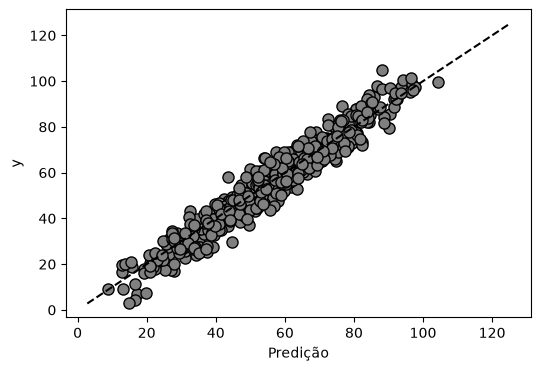

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# mostra os resultados
plt.figure(figsize=(6,4))
l = plt.plot(y_hat, y, 'o', color='gray', markersize=8, 
         markerfacecolor='gray', 
         markeredgecolor='black')

plt.ylabel("y", fontsize=10)
plt.xlabel("Predição", fontsize=10)

# mostra os valores preditos e originais
xl = np.arange(min(y), 1.2*max(y),(max(y)-min(y))/10)
yl = xl
plt.plot(xl, yl, color = 'black', linestyle='--')

plt.show(True)

A curva de convergência.

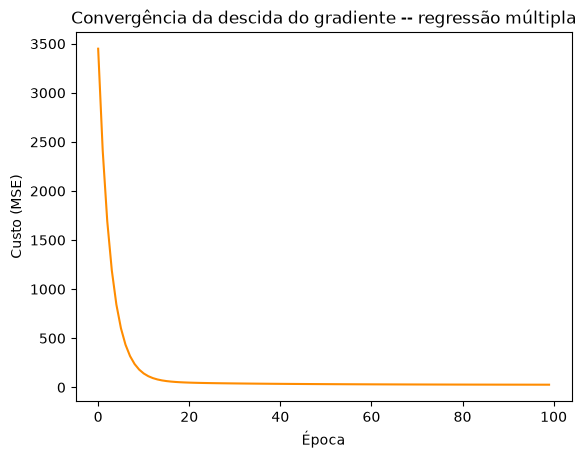

In [6]:
import matplotlib.pyplot as plt

plt.plot(cost_history, color='darkorange')
plt.xlabel('Época')
plt.ylabel('Custo (MSE)')
plt.title('Convergência da descida do gradiente -- regressão múltipla')
plt.show()

Vamos comparar os parâmetros encontrados com a solução exata do scikit-learn. Usamos `fit_intercept=False` porque nossa matriz `X` já contém a coluna de 1's referente ao intercepto, então não queremos que o scikit-learn adicione uma segunda coluna de intercepto por conta própria.

In [7]:
from sklearn.linear_model import LinearRegression

# fit_intercept=False porque X já contém a coluna de 1's do intercepto
model = LinearRegression(fit_intercept=False)
model.fit(X, y)

print("Parâmetros estimados (scikit-learn):")
print(model.coef_)

print("\nComparação, parâmetro a parâmetro:")
for nome, manual, sklearn_val in zip(["intercepto", "beta1", "beta2", "beta3"], beta, model.coef_):
    print(f"  {nome}: descida do gradiente = {manual:.4f}   |   scikit-learn = {sklearn_val:.4f}")

Parâmetros estimados (scikit-learn):
[-0.38005104  1.95533723  4.13215338  5.012531  ]

Comparação, parâmetro a parâmetro:
  intercepto: descida do gradiente = 0.6344   |   scikit-learn = -0.3801
  beta1: descida do gradiente = 2.1736   |   scikit-learn = 1.9553
  beta2: descida do gradiente = 4.0174   |   scikit-learn = 4.1322
  beta3: descida do gradiente = 4.7323   |   scikit-learn = 5.0125


## Regressão logística

Quando a variável-alvo $y$ é categórica, por exemplo, $y=0$ ou $y=1$, representando duas classes, a regressão linear não é adequada. Isso ocorre porque a combinação linear $\beta_0 + \beta_1 x$ pode assumir qualquer valor real, incluindo valores menores que $0$ ou maiores que $1$. Portanto, sua saída não pode ser interpretada diretamente como uma probabilidade.

A **regressão logística** contorna esse problema aplicando a função sigmoide à combinação linear. Essa função transforma qualquer valor real em um número pertencente ao intervalo $(0,1)$:

$$\sigma(z) = \frac{1}{1 + e^{-z}} \qquad\qquad \hat{y}_i = \sigma(\beta_0 + \beta_1 x_i)$$

Assim, a saída do modelo pode ser interpretada como a probabilidade de a observação pertencer à classe $y=1$.

Para treinar o modelo, também precisamos escolher uma função de custo adequada. Embora o erro quadrático médio possa ser aplicado formalmente, ele não é a escolha mais apropriada para a regressão logística: quando combinado com a função sigmoide, pode produzir uma função de custo não convexa, tornando a otimização mais difícil.

Em seu lugar, utiliza-se a **entropia cruzada binária**, também chamada de **binary cross-entropy** ou **log-loss**:

$$J(\beta_0, \beta_1) = -\frac{1}{n}\sum_{i=1}^n \Big[y_i \log(\hat y_i) + (1-y_i)\log(1-\hat y_i)\Big]$$

em que $\hat y_i=P(y_i=1\mid x_i)$ é a probabilidade estimada pelo modelo.

Essa função penaliza fortemente previsões **confiantes e erradas**. Por exemplo, quando $y_i=1$, a contribuição dessa observação para o custo é $-\log(\hat{y}_i)$. Assim, se o modelo atribuir uma probabilidade muito pequena à classe correta, isto é, $\hat y_i\approx 0$, o custo se tornará muito elevado. De modo semelhante, quando $y_i=0$, prever $\hat y_i\approx 1$ também produz uma penalização elevada.

Uma propriedade particularmente conveniente surge ao calcular o gradiente de $J$. Apesar de a função de custo ser diferente daquela usada na regressão linear, suas derivadas apresentam uma forma muito semelhante:

$$\frac{\partial J}{\partial \beta_0} = \frac{1}{n}\sum_{i=1}^n \left(\hat y_i - y_i\right) \qquad\qquad \frac{\partial J}{\partial \beta_1} = \frac{1}{n}\sum_{i=1}^n \left(\hat y_i - y_i\right)x_i.$$

Portanto, o gradiente continua sendo determinado pelo erro entre a previsão e o valor observado, com a diferença de que, na regressão logística, $\hat y_i$ é a probabilidade obtida após a aplicação da função sigmoide:
$$
\hat{y}_i = \sigma\left(\beta_0 + \beta_1 x_i\right)
$$
Os parâmetros podem então ser atualizados pelo método do gradiente descendente:
$$
\beta_j \leftarrow \beta_j - \eta \frac{\partial J}{\partial \beta_j}
$$
em que $\eta$ representa a taxa de aprendizado.

Observe que o sinal do gradiente depende apenas da convenção adotada para definir o erro. Aqui utilizamos $\hat y_i-y_i$; caso o erro fosse definido como $y_i-\hat y_i$, seria necessário ajustar o sinal na expressão de atualização.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Dados de treinamento (classificação binária)
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
y = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1])
n = len(x)

# Inicialização
beta0 = 0.0
beta1 = 0.0

eta = 0.08
epochs = 10000   # a regressão logística costuma exigir mais épocas que a linear para convergir bem

# Função sigmoide: comprime qualquer número real para o intervalo (0, 1)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

cost_history = []

# Treinamento por descida do gradiente
for epoch in range(epochs):
    z = beta0 + beta1 * x
    # probabilidade prevista para a classe 1
    y_hat = sigmoid(z) 

    # note a ordem: aqui é "previsto menos real"
    erro = y_hat - y               

    # Gradientes da entropia cruzada, mesma forma da regressão linear, mudando apenas y_hat
    d_beta0 = (1/n) * np.sum(erro)
    d_beta1 = (1/n) * np.sum(erro * x)

    beta0 = beta0 - eta * d_beta0
    beta1 = beta1 - eta * d_beta1

    # Log-loss (entropia cruzada binária) desta época, para acompanharmos a convergência
    eps = 1e-10   # evita log(0), que resultaria em erro numérico
    custo = -(1/n) * np.sum(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
    cost_history.append(custo)

print("Parâmetros estimados pela descida do gradiente:")
print("beta0 =", beta0)
print("beta1 =", beta1)

Parâmetros estimados pela descida do gradiente:
beta0 = -12.489542226452311
beta1 = 2.8089777526075284


Podemos visualizar a curva sigmoide ajustada e a convergência.

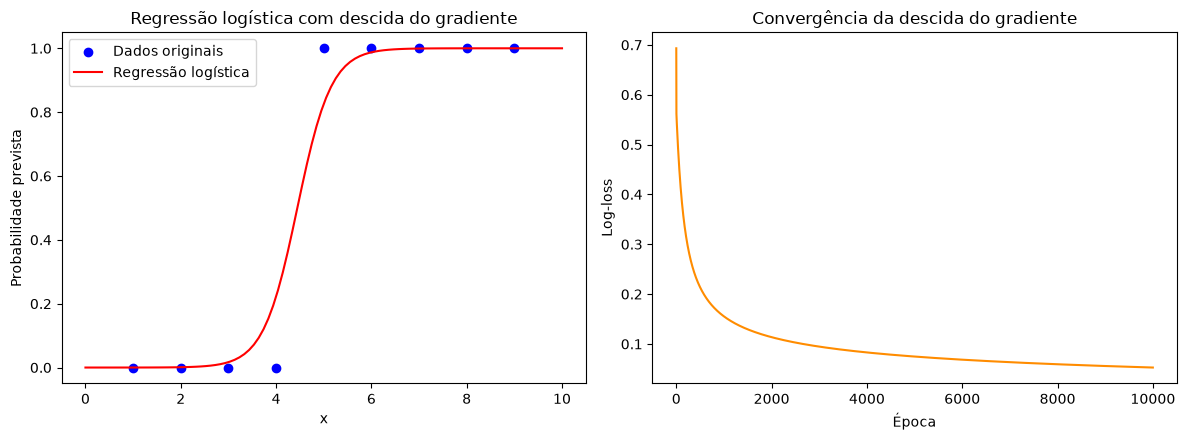

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# --- Gráfico 1: dados e curva sigmoide ajustada ---
x_plot = np.linspace(x.min() - 1, x.max() + 1, 100)
y_plot = sigmoid(beta0 + beta1 * x_plot)

ax1.scatter(x, y, color='blue', label='Dados originais')
ax1.plot(x_plot, y_plot, color='red', label='Regressão logística')
ax1.set_xlabel('x')
ax1.set_ylabel('Probabilidade prevista')
ax1.set_title('Regressão logística com descida do gradiente')
ax1.legend()

# --- Gráfico 2: evolução da log-loss ao longo das épocas ---
ax2.plot(cost_history, color='darkorange')
ax2.set_xlabel('Época')
ax2.set_ylabel('Log-loss')
ax2.set_title('Convergência da descida do gradiente')

plt.tight_layout()
plt.show()

Vamos repetir o ajuste com a classe `LogisticRegression` do scikit-learn, usando um valor de `C` bem grande (o que equivale, na prática, a desativar a regularização) para desativar a regularização (que não usamos na nossa implementação manual), garantindo uma comparação justa entre os dois métodos.

Parâmetros estimados (scikit-learn):
beta0 = -68.30550087578013
beta1 = 15.244226256779017

Comparação com a descida do gradiente (manual):
  beta0: manual = -12.4895   |   scikit-learn = -68.3055
  beta1: manual = 2.8090   |   scikit-learn = 15.2442


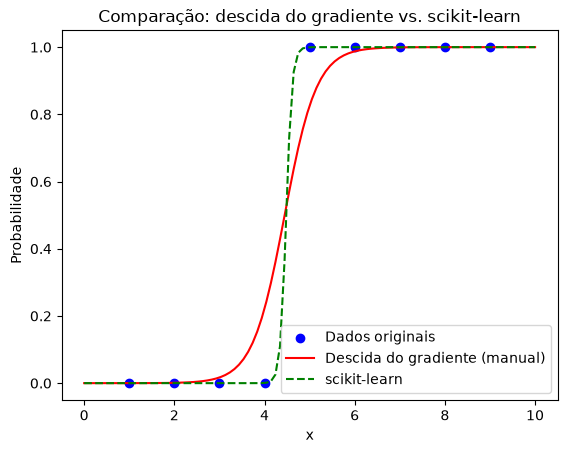

In [10]:
from sklearn.linear_model import LogisticRegression

x_2d = x.reshape(-1, 1)   # o scikit-learn espera os atributos em formato 2D

model = LogisticRegression(
    C=1e10,           # C bem grande equivale, na prática, a "sem regularização" (forma recomendada
                      # atualmente pelo scikit-learn, no lugar do antigo penalty=None)
    solver="lbfgs"    # método de otimização usado internamente pelo scikit-learn
)
model.fit(x_2d, y)

beta1_sk = model.coef_[0][0]
beta0_sk = model.intercept_[0]

print("Parâmetros estimados (scikit-learn):")
print("beta0 =", beta0_sk)
print("beta1 =", beta1_sk)

print("\nComparação com a descida do gradiente (manual):")
print(f"  beta0: manual = {beta0:.4f}   |   scikit-learn = {beta0_sk:.4f}")
print(f"  beta1: manual = {beta1:.4f}   |   scikit-learn = {beta1_sk:.4f}")

# -----------------------------
# Visualização lado a lado das duas curvas
# -----------------------------
y_plot_sk = model.predict_proba(x_plot.reshape(-1, 1))[:, 1]

plt.scatter(x, y, color='blue', label='Dados originais')
plt.plot(x_plot, sigmoid(beta0 + beta1 * x_plot), color='red', label='Descida do gradiente (manual)')
plt.plot(x_plot, y_plot_sk, color='green', linestyle='--', label='scikit-learn')
plt.xlabel('x')
plt.ylabel('Probabilidade')
plt.title('Comparação: descida do gradiente vs. scikit-learn')
plt.legend()
plt.show()

Ao rodar a célula acima, notamos algo estranho: os parâmetros da descida do gradiente manual e os do scikit-learn ficam **bem diferentes** (não apenas uma pequena diferença de arredondamento). Isso **não** é um bug, é uma característica conhecida (e importante de entender) da regressão logística.

> Repare que nosso conjunto de dados é **perfeitamente separável**. Quando isso acontece, **não existe** um único conjunto ótimo de parâmetros, isto é, a função de custo (log-loss) continua diminuindo à medida que $|\beta_1|$ **cresce indefinidamente**, tornando a curva sigmoide cada vez mais parecida com um degrau abrupto entre as duas classes. Em outras palavras, o otimizador está perseguindo um mínimo que só existe "no infinito".

Tanto a nossa descida do gradiente quanto o otimizador L-BFGS do scikit-learn estão, portanto, correndo atrás do mesmo alvo inatingível. A diferença nos valores finais reflete apenas o quão **longe** cada algoritmo chegou nessa corrida (o L-BFGS do scikit-learn converge de forma mais agressiva, chegando mais longe em menos iterações). Se treinássemos por muito mais épocas, os parâmetros da nossa versão manual também cresceriam cada vez mais, sem nunca se estabilizar.

Apesar de os **parâmetros** serem bem diferentes, observe no gráfico que as **curvas ajustadas** ficam parecidas na região onde há dados (ambas separam bem as duas classes). É o comportamento nas bordas, longe dos dados observados, que mais diverge entre os dois modelos. Na prática, esse problema é resolvido aplicando **regularização** (por exemplo, `penalty='l2'` no scikit-learn), que penaliza coeficientes grandes e impede esse crescimento descontrolado, mas isso foge do escopo deste notebook, focado na mecânica da descida do gradiente em si.

## Aplicação em dados reais

Para concluir o notebook, aplicaremos a regressão logística, treinada por descida do gradiente, à classificação das espécies da flor íris. Vamos distinguir duas espécies, isto é, *Iris versicolor* e *Iris virginica*, utilizando apenas um atributo.

Diferentemente do exemplo perfeitamente separável da seção anterior, essas duas classes apresentam sobreposição quando consideramos somente o atributo `sepal width`. Assim, não esperamos que os parâmetros cresçam indefinidamente na tentativa de separar todas as observações. A função de custo deve possuir um mínimo finito, e a descida do gradiente deve convergir normalmente para uma solução bem definida.

Esta última implementação também introduz dois elementos que ainda não havíamos calculado: a *fronteira de decisão* e a *acurácia* do modelo no conjunto de treinamento.

A fronteira de decisão corresponde ao valor de $x$ para o qual o modelo atribui a mesma probabilidade às duas classes, isto é,
$$
\hat{y} = 0{,}5.
$$
Como a função sigmoide assume o valor $0{,}5$ quando seu argumento é igual a zero, a fronteira de decisão é obtida resolvendo
$$
\beta_0 + \beta_1 x = 0.
$$
Portanto,
$$
x_{\text{fronteira}}
=
-\frac{\beta_0}{\beta_1}.
$$
Também calcularemos a acurácia do modelo, isto é, a proporção de observações classificadas corretamente. Para converter as probabilidades estimadas em classes, adotaremos $0{,}5$ como limiar de decisão:
$$
\hat{c}_i =
\begin{cases}
1, & \text{se } \hat{y}_i \geq 0{,}5,\\
0, & \text{se } \hat{y}_i < 0{,}5.
\end{cases}
$$
A acurácia é então calculada por
$$
\text{Ac}
=
\frac{1}{n}
\sum_{i=1}^{n}
\mathbb{I}\left(\hat{c}_i = y_i\right),
$$
em que $\mathbb{I}(\cdot)$ é a função indicadora, que assume o valor $1$ quando a classificação está correta e $0$ caso contrário.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Carrega os dados da Iris
iris = load_iris()
print('Features:', iris.feature_names)

# Vamos usar apenas duas das três classes originais da Iris:
# 0 = setosa
# 1 = versicolor
X_all = iris.data
y_all = iris.target

# mantém somente as classes 0 e 1 (descarta a classe 2, virginica)
mask = y_all < 2  
X_all = X_all[mask]
y = y_all[mask]

# Escolhe um único atributo. Aqui usamos petal length (cm), que é a coluna de índice 2
i = 1
print('Atributo usado:', iris.feature_names[i])
x = X_all[:, i]

# Função sigmoide
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Inicialização
n = len(x)
beta0 = 0.0
beta1 = 0.0

eta = 0.5
epochs = 5000

# Lista para armazenar o valor da função de custo a cada época
cost_history = []

# Treinamento por descida do gradiente
for epoch in range(epochs):
    z = beta0 + beta1 * x
    y_hat = sigmoid(z)

    erro = y_hat - y

    # Gradientes (mesma fórmula da Seção "Regressão logística")
    d_beta0 = (1 / n) * np.sum(erro)
    d_beta1 = (1 / n) * np.sum(erro * x)

    # Atualização dos parâmetros
    beta0 = beta0 - eta * d_beta0
    beta1 = beta1 - eta * d_beta1

    # Cálculo da log-loss (entropia cruzada binária) desta época
    eps = 1e-10
    cost = -(1 / n) * np.sum(
        y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps)
    )
    cost_history.append(cost)

# Resultados
print("Parâmetros estimados:")
print("beta0 =", beta0)
print("beta1 =", beta1)

# A fronteira de decisão é o valor de x para o qual beta0 + beta1*x = 0
# (ou seja, onde a probabilidade prevista é exatamente 0.5)
x_decisao = -beta0 / beta1
print("Fronteira de decisão x* =", x_decisao)

# Classificação final e acurácia
y_prob = sigmoid(beta0 + beta1 * x)
y_pred = (y_prob >= 0.5).astype(int)   # classifica como 1 se a probabilidade prevista for >= 50%

acuracia = np.mean(y_pred == y)
print("Acurácia =", acuracia)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Atributo usado: sepal width (cm)
Parâmetros estimados:
beta0 = 17.854504019844583
beta1 = -5.783960053299664
Fronteira de decisão x* = 3.0868996077624797
Acurácia = 0.84


Vamos conferir tanto a curva logística ajustada (junto com a fronteira de decisão) quanto a evolução da log-loss ao longo do treinamento.

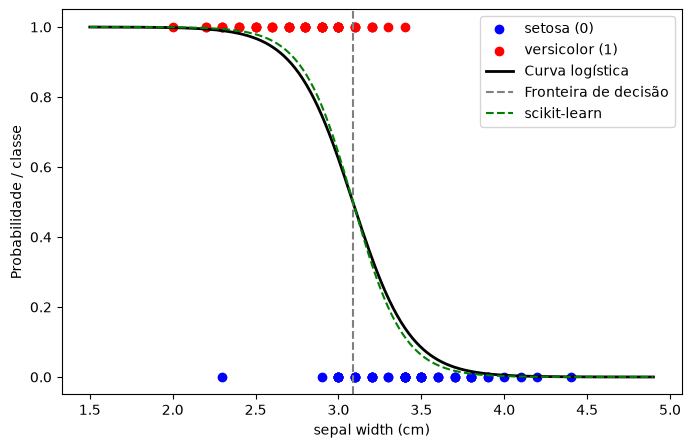

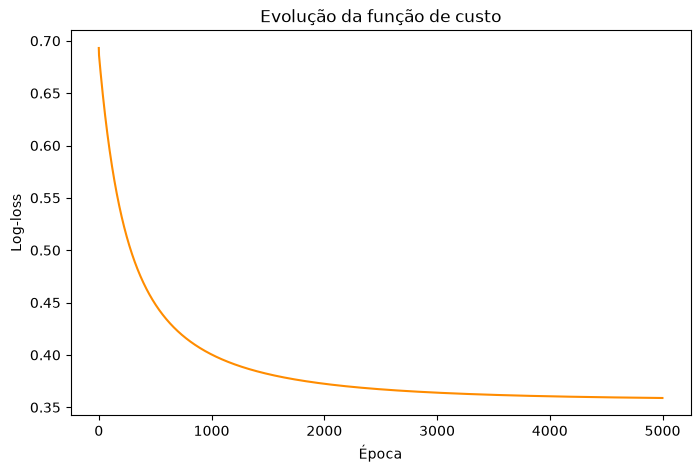

In [12]:
plt.figure(figsize=(8, 5))

#################
# Gráfico da curva logística e da fronteira de decisão
x_plot = np.linspace(x.min() - 0.5, x.max() + 0.5, 300)
y_plot = sigmoid(beta0 + beta1 * x_plot)

plt.scatter(x[y == 0], y[y == 0], color="blue", label="setosa (0)")
plt.scatter(x[y == 1], y[y == 1], color="red", label="versicolor (1)")
# plot da descida do gradiente
plt.plot(x_plot, y_plot, color="black", linewidth=2, label="Curva logística")
plt.axvline(x_decisao, color="gray", linestyle="--", label="Fronteira de decisão")

# curva do scikit-learn
# sklearn
x_2d = x.reshape(-1, 1)   # o scikit-learn espera os atributos em formato 2D
model = LogisticRegression(
    C=1e10,           # C bem grande equivale, na prática, a "sem regularização" 
    solver="lbfgs"    # método de otimização usado internamente pelo scikit-learn
)
model.fit(x_2d, y)
y_plot_sk = model.predict_proba(x_plot.reshape(-1, 1))[:, 1]
plt.plot(x_plot, y_plot_sk, color='green', linestyle='--', label='scikit-learn')


plt.xlabel(iris.feature_names[i])
plt.ylabel("Probabilidade / classe")
plt.legend()
plt.show()

# Gráfico da função de custo
plt.figure(figsize=(8, 5))
plt.plot(cost_history, color="darkorange")
plt.xlabel("Época")
plt.ylabel("Log-loss")
plt.title("Evolução da função de custo")
plt.show()

Diferentemente do exemplo da seção anterior, aqui as duas espécies **não** são perfeitamente separáveis, então a log-loss converge suavemente para um valor estável, sem o comportamento "em fuga" que discutimos antes. Esse é exatamente o comportamento bem-posto que esperamos da regressão logística na maioria dos problemas reais.

## Conclusão

1. a descida do gradiente segue sempre a mesma receita: calcular o gradiente da função de custo em relação a cada parâmetro, e dar um passo na direção oposta, de tamanho proporcional à taxa de aprendizado $\eta$;
2. **sempre acompanhe a curva de custo por época**: ela é o principal termômetro para saber se o algoritmo está convergindo, divergindo (custo aumentando) ou apenas convergindo devagar demais;
3. apesar de a regressão linear e a regressão logística terem funções de custo bem diferentes (MSE vs. log-loss), o **gradiente** de ambas tem a mesma forma elegante: $\frac{1}{n}\sum (\text{previsto} - \text{real}) \times \text{atributo}$;
4. dados perfeitamente (ou quase perfeitamente) separáveis são um problema conhecido para a regressão logística **sem regularização**: os parâmetros podem crescer indefinidamente, sem nunca convergir para um valor finito estável;
5. comparar uma implementação manual com a solução de referência de uma biblioteca consolidada (como o scikit-learn) é uma prática valiosa tanto para **validar o código** quanto para **aprender algo nos casos em que os resultados não batem**, como vimos na regressão logística.

### Exercícios de fixação

1. Na regressão linear simples, experimente valores bem diferentes de `eta` (por exemplo, `0.001`, `0.1` e `0.5`) e observe o efeito na curva de custo. Em algum desses casos, o algoritmo diverge (custo aumentando em vez de diminuir)?

eta = 0.001: beta0 = 0.2306, beta1 = 1.263, custo inicial = 54.1, custo final = 0.9953
eta = 0.1: beta0 = -3.851e+33, beta1 = -2.415e+34, custo inicial = 54.1, custo final = 7.448e+68
eta = 0.5: beta0 = -7.137e+71, beta1 = -4.476e+72, custo inicial = 54.1, custo final = 7.537e+143


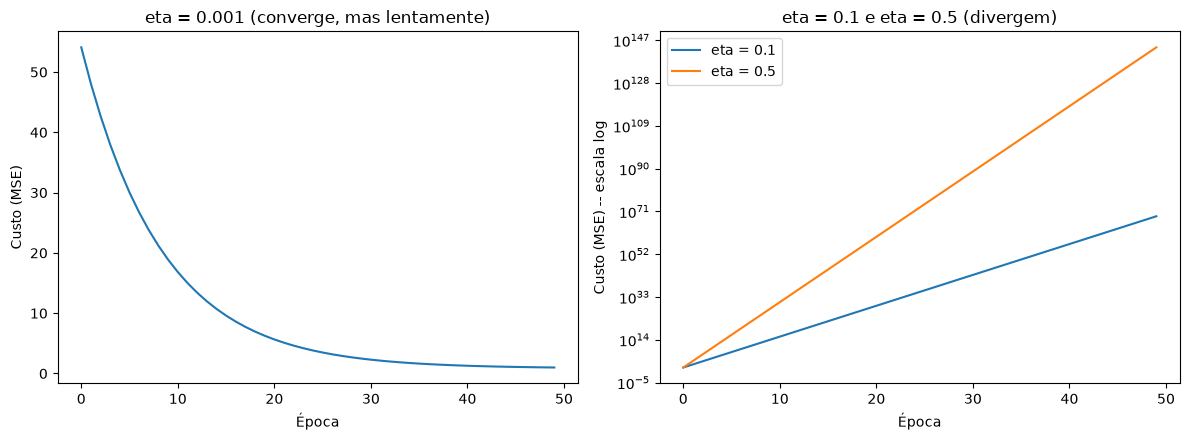

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Mesmos dados de treinamento da regressão linear simples
x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
y = np.array([1, 3, 2, 5, 7, 8, 8, 9, 10, 12])
n = len(x)


def gradiente_descendente_linear(x, y, eta, epochs=50):
    """Repete o treinamento da Seção 1, agora como função, para poder variar eta facilmente."""
    n = len(x)
    beta0, beta1 = 0.0, 0.0
    cost_history = []

    for epoch in range(epochs):
        y_hat = beta0 + beta1 * x
        erro = y - y_hat

        d_beta0 = (-2 / n) * np.sum(erro)
        d_beta1 = (-2 / n) * np.sum(erro * x)

        beta0 = beta0 - eta * d_beta0
        beta1 = beta1 - eta * d_beta1

        cost_history.append(np.mean(erro ** 2))

    return beta0, beta1, cost_history


etas = [0.001, 0.1, 0.5] # taxas de aprendizado a serem testadas
resultados = {}

for eta in etas:
    beta0, beta1, cost_history = gradiente_descendente_linear(x, y, eta, epochs=50)
    resultados[eta] = cost_history
    print(f"eta = {eta}: beta0 = {beta0:.4g}, beta1 = {beta1:.4g}, "
          f"custo inicial = {cost_history[0]:.4g}, custo final = {cost_history[-1]:.4g}")

# Como os custos ficam em escalas muito diferentes (de ~1 até números gigantescos
# quando o algoritmo diverge), usamos dois gráficos: um em escala normal (eta pequeno,
# que converge) e outro em escala logarítmica no eixo y (para visualizar a divergência).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(resultados[0.001], color='tab:blue')
ax1.set_xlabel('Época')
ax1.set_ylabel('Custo (MSE)')
ax1.set_title('eta = 0.001 (converge, mas lentamente)')

for eta in [0.1, 0.5]:
    ax2.plot(resultados[eta], label=f'eta = {eta}')
ax2.set_yscale('log')
ax2.set_xlabel('Época')
ax2.set_ylabel('Custo (MSE) -- escala log')
ax2.set_title('eta = 0.1 e eta = 0.5 (divergem)')
ax2.legend()

plt.tight_layout()
plt.show()

2. Na regressão logística com a base Iris, repita o experimento usando um segundo atributo (por exemplo, *sepal length*) e compare a acurácia obtida.

Atributo: sepal width (cm)
  beta0 = 17.8545, beta1 = -5.7840
  Fronteira de decisão x* = 3.0869
  Acurácia = 0.8400

Atributo: sepal length (cm)
  beta0 = -23.8534, beta1 = 4.4045
  Fronteira de decisão x* = 5.4157
  Acurácia = 0.8900



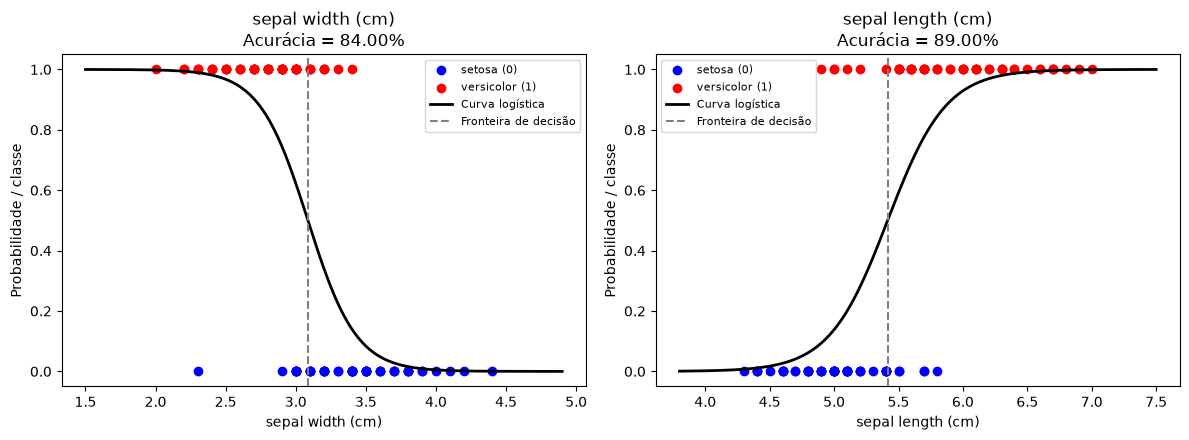

Comparação final de acurácia:
  sepal width (cm): acurácia = 84.00%
  sepal length (cm): acurácia = 89.00%


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Carrega os dados da Iris (mesmas duas classes usadas na Seção "Aplicação em dados reais")
iris = load_iris()
X_all = iris.data
y_all = iris.target

mask = y_all < 2
X_all = X_all[mask]
y = y_all[mask]


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def treinar_logistica(x, y, eta=0.5, epochs=5000):
    n = len(x)
    beta0, beta1 = 0.0, 0.0
    cost_history = []

    for epoch in range(epochs):
        z = beta0 + beta1 * x
        y_hat = sigmoid(z)
        erro = y_hat - y

        d_beta0 = (1 / n) * np.sum(erro)
        d_beta1 = (1 / n) * np.sum(erro * x)

        beta0 = beta0 - eta * d_beta0
        beta1 = beta1 - eta * d_beta1

        eps = 1e-10
        cost = -(1 / n) * np.sum(
            y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps)
        )
        cost_history.append(cost)

    return beta0, beta1, cost_history


# Compara os dois atributos: sepal width (usado no notebook) e sepal length (novo)
atributos = {
    'sepal width (cm)': 1,
    'sepal length (cm)': 0,
}

resultados = {}

for nome, indice in atributos.items():
    x = X_all[:, indice]

    beta0, beta1, cost_history = treinar_logistica(x, y)

    y_prob = sigmoid(beta0 + beta1 * x)
    y_pred = (y_prob >= 0.5).astype(int)
    acuracia = np.mean(y_pred == y)
    x_decisao = -beta0 / beta1

    resultados[nome] = dict(x=x, beta0=beta0, beta1=beta1,
                             cost_history=cost_history,
                             acuracia=acuracia, x_decisao=x_decisao)

    print(f"Atributo: {nome}")
    print(f"  beta0 = {beta0:.4f}, beta1 = {beta1:.4f}")
    print(f"  Fronteira de decisão x* = {x_decisao:.4f}")
    print(f"  Acurácia = {acuracia:.4f}\n")

# -----------------------------
# Comparação visual: curva logística ajustada para cada atributo
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (nome, r) in zip(axes, resultados.items()):
    x = r['x']
    x_plot = np.linspace(x.min() - 0.5, x.max() + 0.5, 300)
    y_plot = sigmoid(r['beta0'] + r['beta1'] * x_plot)

    ax.scatter(x[y == 0], y[y == 0], color='blue', label='setosa (0)')
    ax.scatter(x[y == 1], y[y == 1], color='red', label='versicolor (1)')
    ax.plot(x_plot, y_plot, color='black', linewidth=2, label='Curva logística')
    ax.axvline(r['x_decisao'], color='gray', linestyle='--', label='Fronteira de decisão')
    ax.set_xlabel(nome)
    ax.set_ylabel('Probabilidade / classe')
    ax.set_title(f"{nome}\nAcurácia = {r['acuracia']:.2%}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Comparação final de acurácia:")
for nome, r in resultados.items():
    print(f"  {nome}: acurácia = {r['acuracia']:.2%}")